In [1]:
!pip install "datasets>=2.18.0,<3"
!pip install transformers>=4.38.2 
!pip install sentence-transformers>=2.5.1 
!pip install setfit>=1.0.3 
!pip install accelerate>=0.27.2 
!pip install seqeval>=1.2.2

### Data


In [2]:
from datasets import load_dataset

# Prepare data splits
tomatoes = load_dataset('rotten_tomatoes')
train_data, test_data = tomatoes['train'], tomatoes['test']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


## Supervised classification


### HuggingFace Trainer


In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load model and tokenizer
model_id = 'bert-base-cased'
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=2)
tokenizer = AutoTokenizer.from_pretrained(model_id)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [4]:
def preprocess_function(examples):
    '''Tokenize input data'''
    
    return tokenizer(examples['text'], truncation=True)

In [5]:
from transformers import DataCollatorWithPadding

# Pad to the longest sequence in the batch
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenized_train = train_data.map(preprocess_function, batched=True)
tokenized_test = train_data.map(preprocess_function, batched=True)

#### Define metrics


In [6]:
import numpy as np
import evaluate

def compute_metrics(eval_pred):
    '''Calculate F1 score'''
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    load_f1 = evaluate.load('f1')
    f1 = load_f1.compute(predictions=predictions, references=labels)['f1']
    
    return {
        'f1': f1
    }
    

#### Train model


In [7]:
from transformers import TrainingArguments, Trainer

# Training arguments for parameter tuning
training_args = TrainingArguments(
    'model',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    save_strategy='epoch',
    report_to='none'
)

# Trainer which executes the training process
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

/tmp/ipython-input-3937296302.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [8]:
trainer.train()

Step,Training Loss
500,0.406600


TrainOutput(global_step=534, training_loss=0.40401936648936754, metrics={'train_runtime': 95.1274, 'train_samples_per_second': 89.669, 'train_steps_per_second': 5.614, 'total_flos': 227605451772240.0, 'train_loss': 0.40401936648936754, 'epoch': 1.0})

#### Evaluate metrics


In [9]:
trainer.evaluate()

{'eval_loss': 0.22663916647434235,
 'eval_f1': 0.9166375189460184,
 'eval_runtime': 25.7021,
 'eval_samples_per_second': 331.88,
 'eval_steps_per_second': 20.777,
 'epoch': 1.0}

### Freeze layers


In [10]:
# Load model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=2)

tokenizer = AutoTokenizer.from_pretrained(model_id)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [11]:
# Print layer names
for name, param in model.named_parameters():
    print(name)

bert.embeddings.word_embeddings.weight
bert.embeddings.position_embeddings.weight
bert.embeddings.token_type_embeddings.weight
bert.embeddings.LayerNorm.weight
bert.embeddings.LayerNorm.bias
bert.encoder.layer.0.attention.self.query.weight
bert.encoder.layer.0.attention.self.query.bias
bert.encoder.layer.0.attention.self.key.weight
bert.encoder.layer.0.attention.self.key.bias
bert.encoder.layer.0.attention.self.value.weight
bert.encoder.layer.0.attention.self.value.bias
bert.encoder.layer.0.attention.output.dense.weight
bert.encoder.layer.0.attention.output.dense.bias
bert.encoder.layer.0.attention.output.LayerNorm.weight
bert.encoder.layer.0.attention.output.LayerNorm.bias
bert.encoder.layer.0.intermediate.dense.weight
bert.encoder.layer.0.intermediate.dense.bias
bert.encoder.layer.0.output.dense.weight
bert.encoder.layer.0.output.dense.bias
bert.encoder.layer.0.output.LayerNorm.weight
bert.encoder.layer.0.output.LayerNorm.bias
bert.encoder.layer.1.attention.self.query.weight
bert.enc

In [12]:
for name, param in model.named_parameters():
    # Trainable classification head
    if name.startswith('classifier'):
        param.required_grad = True
        
    # Freeze everything else
    else:
        param.requires_grad = False

In [13]:
# We can check whether the model was correctly updated
for name, param in model.named_parameters():
    print(f'Parameter: {name} ---- {param.requires_grad}')

Parameter: bert.embeddings.word_embeddings.weight ---- False
Parameter: bert.embeddings.position_embeddings.weight ---- False
Parameter: bert.embeddings.token_type_embeddings.weight ---- False
Parameter: bert.embeddings.LayerNorm.weight ---- False
Parameter: bert.embeddings.LayerNorm.bias ---- False
Parameter: bert.encoder.layer.0.attention.self.query.weight ---- False
Parameter: bert.encoder.layer.0.attention.self.query.bias ---- False
Parameter: bert.encoder.layer.0.attention.self.key.weight ---- False
Parameter: bert.encoder.layer.0.attention.self.key.bias ---- False
Parameter: bert.encoder.layer.0.attention.self.value.weight ---- False
Parameter: bert.encoder.layer.0.attention.self.value.bias ---- False
Parameter: bert.encoder.layer.0.attention.output.dense.weight ---- False
Parameter: bert.encoder.layer.0.attention.output.dense.bias ---- False
Parameter: bert.encoder.layer.0.attention.output.LayerNorm.weight ---- False
Parameter: bert.encoder.layer.0.attention.output.LayerNorm.bia

In [14]:
from transformers import TrainingArguments, Trainer

# Train which executes the training process
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

/tmp/ipython-input-2811005792.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.694700


TrainOutput(global_step=534, training_loss=0.6948552792438407, metrics={'train_runtime': 28.6239, 'train_samples_per_second': 298.003, 'train_steps_per_second': 18.656, 'total_flos': 227605451772240.0, 'train_loss': 0.6948552792438407, 'epoch': 1.0})

In [15]:
trainer.evaluate()

{'eval_loss': 0.6826683282852173,
 'eval_f1': 0.6377830627649674,
 'eval_runtime': 25.7042,
 'eval_samples_per_second': 331.853,
 'eval_steps_per_second': 20.775,
 'epoch': 1.0}

### Freeze blocks 1 - 5


In [16]:
# We can check whether the model was correctly updated
for index, (name, param) in enumerate(model.named_parameters()):
    print(f'Parameter: {index} {name} ---- {param.requires_grad}')

Parameter: 0 bert.embeddings.word_embeddings.weight ---- False
Parameter: 1 bert.embeddings.position_embeddings.weight ---- False
Parameter: 2 bert.embeddings.token_type_embeddings.weight ---- False
Parameter: 3 bert.embeddings.LayerNorm.weight ---- False
Parameter: 4 bert.embeddings.LayerNorm.bias ---- False
Parameter: 5 bert.encoder.layer.0.attention.self.query.weight ---- False
Parameter: 6 bert.encoder.layer.0.attention.self.query.bias ---- False
Parameter: 7 bert.encoder.layer.0.attention.self.key.weight ---- False
Parameter: 8 bert.encoder.layer.0.attention.self.key.bias ---- False
Parameter: 9 bert.encoder.layer.0.attention.self.value.weight ---- False
Parameter: 10 bert.encoder.layer.0.attention.self.value.bias ---- False
Parameter: 11 bert.encoder.layer.0.attention.output.dense.weight ---- False
Parameter: 12 bert.encoder.layer.0.attention.output.dense.bias ---- False
Parameter: 13 bert.encoder.layer.0.attention.output.LayerNorm.weight ---- False
Parameter: 14 bert.encoder.lay

In [17]:
# Loading the model
model_id = 'bert-base-cased'
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=2)
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Encoder block 10 starts at index 165 and we freeze everything before that block
for index, (name, param) in enumerate(model.named_parameters()):
    if index < 165:
        param.requires_grad = False
        
# Trainer which executes the training process
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_test,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1327099893.py:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [18]:
trainer.train()

Step,Training Loss
500,0.476100


TrainOutput(global_step=534, training_loss=0.47253813368550845, metrics={'train_runtime': 38.3399, 'train_samples_per_second': 222.484, 'train_steps_per_second': 13.928, 'total_flos': 227605451772240.0, 'train_loss': 0.47253813368550845, 'epoch': 1.0})

In [19]:
trainer.evaluate()

{'eval_loss': 0.3722224235534668,
 'eval_f1': 0.8367371030574903,
 'eval_runtime': 25.6975,
 'eval_samples_per_second': 331.939,
 'eval_steps_per_second': 20.78,
 'epoch': 1.0}

### [BONUS] Freeze blocks


In [20]:
scores = []

for index in range(12):
    print('\nIndex:', index)
    
    # Re load the model
    model = AutoModelForSequenceClassification.from_pretrained('bert-base-cased', num_labels=2)
    tokenizer = AutoTokenizer.from_pretrained('bert-base-cased')
    
    # Freeze encoder blocks 0-index
    for name, param in model.named_parameters():
        if 'layer' in name:
            layer_nr = int(name.split('layer')[1].split('.')[1])
            
            if layer_nr <= index:
                param.requires_grad = False
                
        else:
            param.requires_grad = True
            
    # Train
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )
    
    trainer.train()
    
    # Evaluate
    score = trainer.evaluate()['eval_f1']
    scores.append(score)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Index: 0


/tmp/ipython-input-1356138021.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.405600


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Step,Training Loss
500,0.518100


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Index: 11


/tmp/ipython-input-1356138021.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.655600


In [21]:
scores

[0.9164527421236873,
 0.9121534682418997,
 0.9072863148061654,
 0.8995927865037813,
 0.8945029239766081,
 0.887874531835206,
 0.8778831518557546,
 0.8666040394551433,
 0.856301531213192,
 0.844950213371266,
 0.8189990281827016,
 0.7047962170682279]

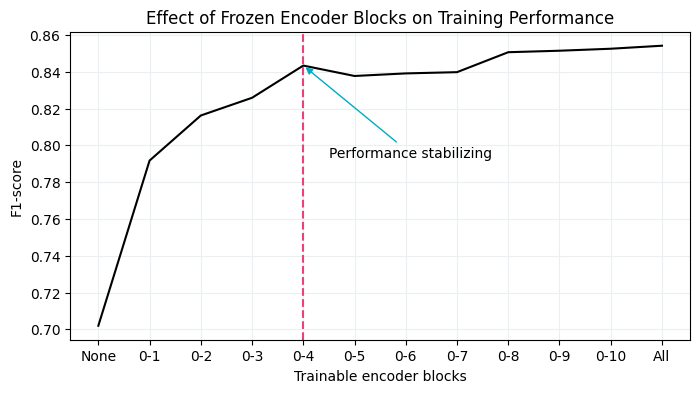

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Create Figure
plt.figure(figsize=(8,4))

# Prepare Data
x = [f"0-{index}" for index in range(12)]
x[0] = "None"
x[-1] = "All"
y = [
    0.8541862652869239,
    0.8525519848771267,
    0.8514664143803217,
    0.8506616257088847,
    0.8398104265402844,
    0.8391345249294448,
    0.8377358490566037,
    0.8433962264150944,
    0.8258801141769743,
    0.816247582205029,
    0.7917485265225934,
    0.7019400352733686
][::-1]

# Stylize Figure
plt.grid(color='#ECEFF1')
plt.axvline(x=4, color="#EC407A", linestyle="--")
plt.title("Effect of Frozen Encoder Blocks on Training Performance")
plt.ylabel("F1-score")
plt.xlabel("Trainable encoder blocks")

# Plot Data
plt.plot(x, y, color="black")

# Additional Annotation
plt.annotate(
    'Performance stabilizing',
    xy=(4, y[4]),
    xytext=(4.5, y[4]-.05),
    arrowprops=dict(
        arrowstyle="-|>",
        connectionstyle="arc3",
        color="#00ACC1")
)

plt.savefig("multiple_frozen_blocks.png", dpi=300, bbox_inches='tight')

### Few shot classification


In [23]:
from setfit import sample_dataset


# We simulate a few-shot setting by sampling 16 examples per class
sampled_train_data = sample_dataset(tomatoes['train'], num_samples=16)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [24]:
from setfit import SetFitModel

# Load a pre-trained SentenceTransformer model
model = SetFitModel.from_pretrained('sentence-transformers/all-mpnet-base-v2')

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


In [25]:
from setfit import TrainingArguments as SetFitTrainingArguments
from setfit import Trainer as SetFitTrainer

# Define training arguments
args = SetFitTrainingArguments(
    num_epochs=3, # the number of epochs to use for contrastive learning,
    num_iterations=20 # the number of text pairs to generate
)

args.eval_strategy = args.evaluation_strategy

# Create trainer
trainer = SetFitTrainer(
    model=model,
    args=args,
    train_dataset=sampled_train_data,
    eval_dataset=test_data,
    metric='f1'
)

/usr/local/lib/python3.12/dist-packages/datasets/utils/_dill.py:385: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  obj.co_lnotab,  # for < python 3.10 [not counted in args]
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Map:   0%|          | 0/32 [00:00<?, ? examples/s]

In [26]:
# Create trainer
# trainer = SetFitTrainer(
#     model=model,
#     train_dataset=sampled_train_data,
#     eval_dataset=test_data,
#     metric='f1',
#     num_epochs=3 # epochs for contrastive learning
# )

In [27]:
# Training loop
trainer.train()

***** Running training *****
  Num unique pairs = 1280
  Batch size = 16
  Num epochs = 3
wandb: Currently logged in as: akshaysoam8 (akshaysoam8-dan-com-a-godaddy-brand) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:279: DeprecationWarning: The `Scope.user` setter is deprecated in favor of `Scope.set_user()`.
  self.scope.user = {"email": email}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:279: DeprecationWarning: The `Scope.user` setter is deprecated in favor of `Scope.set_user()`.
  self.scope.user = {"email": email}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/google/protobuf/internal/well_known_types.py:178: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  self.FromDatetime(datetime.datetime.utcnow())
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


Step,Training Loss,Validation Loss


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/google/protobuf/internal/well_known_types.py:178: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  self.FromDatetime(datetime.datetime.utcnow())
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/google/protobuf/internal/well_known_types.py:

In [28]:
trainer.evaluate()

***** Running evaluation *****
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/google/protobuf/internal/well_known_types.py:178: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  self.FromDatetime(datetime.datetime.utcnow())


{'f1': 0.8454011741682974}

In [29]:
model.model_head

LogisticRegression()

## Masked language modeling (MLM)


In [30]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

# Load model for masked language modeling (MLM)
model = AutoModelForMaskedLM.from_pretrained('bert-base-cased')
tokenizer = AutoTokenizer.from_pretrained('bert-base-cased')

Some weights of the model checkpoint at bert-base-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [31]:
def preprocess_function(examples):
    return tokenizer(examples['text'], truncation=True)

# Tokenized data
tokenized_train = train_data.map(preprocess_function, batched=True)
tokenized_train = tokenized_train.remove_columns('label')

tokenized_test = train_data.map(preprocess_function, batched=True)
tokenized_test = tokenized_test.remove_columns('label')

/usr/local/lib/python3.12/dist-packages/datasets/utils/_dill.py:385: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  obj.co_lnotab,  # for < python 3.10 [not counted in args]


In [32]:
from transformers import DataCollatorForLanguageModeling

# Masked tokens
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15
)

In [33]:
# from transformers import DataCollatorForWholeWordMask

# # Masking whole words
# data_collator = DataCollatorForWholeWordMask(
#     tokenizer=tokenizer,
#     mlm=True,
#     mlm_probability=0.15
# )

In [34]:
# Training arguments for parameter tuning
training_args = TrainingArguments(
    'model',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    save_strategy='epoch',
    report_to='none'
)

# Initiate trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator
)

/tmp/ipython-input-109788846.py:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/google/protobuf/internal/well_known_types.py:178: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  self.FromDatetime(datetime.datetime.utcnow())
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [35]:
# Save pre-trained tokenizer
tokenizer.save_pretrained('mlm')

('mlm/tokenizer_config.json',
 'mlm/special_tokens_map.json',
 'mlm/vocab.txt',
 'mlm/added_tokens.json',
 'mlm/tokenizer.json')

In [36]:
# Train model
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


Step,Training Loss
500,2.604500
1000,2.371400
1500,2.306700
2000,2.191000
2500,2.150500
3000,2.089400
3500,2.053600
4000,1.993700
4500,1.987100
5000,1.955500


/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/google/protobuf/internal/well_known_types.py:178: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  self.FromDatetime(datetime.datetime.utcnow())
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/jupyter_client/sessi

TrainOutput(global_step=5340, training_loss=2.1572584402248656, metrics={'train_runtime': 1479.7255, 'train_samples_per_second': 57.646, 'train_steps_per_second': 3.609, 'total_flos': 2273819807394096.0, 'train_loss': 2.1572584402248656, 'epoch': 10.0})

In [37]:
model.save_pretrained('mlm')

In [38]:
from transformers import pipeline

# Load and create predictions
mask_filler = pipeline('fill-mask', model='bert-base-cased')
preds = mask_filler('What a horrible [MASK]!')

for pred in preds:
    print(f'>> {pred['sequence']}')

Some weights of the model checkpoint at bert-base-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


>> What a horrible idea!
>> What a horrible dream!
>> What a horrible thing!
>> What a horrible day!
>> What a horrible thought!


In [39]:
# Load and create predictions
mask_filler = pipeline('fill-mask', model='mlm')
preds = mask_filler('What a horrible [MASK]!')

for pred in preds:
    print(f'>>> {pred['sequence']}')

Device set to use cuda:0


>>> What a horrible movie!
>>> What a horrible film!
>>> What a horrible mess!
>>> What a horrible comedy!
>>> What a horrible story!


## Named entity recognition


In [40]:
from transformers import AutoModelForTokenClassification, AutoTokenizer
from transformers import DataCollatorWithPadding
from transformers import TrainingArguments, Trainer

dataset = load_dataset('conll2003', trust_remote_code=True)

In [41]:
example = dataset['train'][848]
example

{'id': '848',
 'tokens': ['Dean',
  'Palmer',
  'hit',
  'his',
  '30th',
  'homer',
  'for',
  'the',
  'Rangers',
  '.'],
 'pos_tags': [22, 22, 38, 29, 16, 21, 15, 12, 23, 7],
 'chunk_tags': [11, 12, 21, 11, 12, 12, 13, 11, 12, 0],
 'ner_tags': [1, 2, 0, 0, 0, 0, 0, 0, 3, 0]}

In [42]:
label2id = {
    'O': 0,
    'B-PER': 1,
    'I-PER': 2,
    'B-ORG': 3,
    'I-ORG': 4,
    'B-LOC': 5,
    'I-LOC': 6,
    'B-MISC': 7,
    'I-MISC': 8
}

id2label = {
    index: label for label, index in label2id.items()
}

id2label

{0: 'O',
 1: 'B-PER',
 2: 'I-PER',
 3: 'B-ORG',
 4: 'I-ORG',
 5: 'B-LOC',
 6: 'I-LOC',
 7: 'B-MISC',
 8: 'I-MISC'}

In [43]:
from transformers import AutoModelForTokenClassification

tokenizer = AutoTokenizer.from_pretrained('bert-base-cased')

model = AutoModelForTokenClassification.from_pretrained('bert-base-cased', num_labels=len(id2label), id2label=id2label, label2id=label2id)

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [44]:
token_ids = tokenizer(example['tokens'], is_split_into_words=True)['input_ids']
sub_tokens = tokenizer.convert_ids_to_tokens(token_ids)
sub_tokens

['[CLS]',
 'Dean',
 'Palmer',
 'hit',
 'his',
 '30th',
 'home',
 '##r',
 'for',
 'the',
 'Rangers',
 '.',
 '[SEP]']

In [45]:
def align_labels(examples):
    tokenized = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True
    )

    all_labels = []

    for i, labels in enumerate(examples["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        prev_word_id = None
        label_ids = []

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word_id:
                label_ids.append(labels[word_id])
            else:
                # ignore subword tokens
                label_ids.append(-100)

            prev_word_id = word_id

        all_labels.append(label_ids)

    tokenized["labels"] = all_labels
    return tokenized

In [46]:
tokenized = dataset.map(align_labels, batched=True)

/usr/local/lib/python3.12/dist-packages/datasets/utils/_dill.py:385: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  obj.co_lnotab,  # for < python 3.10 [not counted in args]


In [47]:
# difference between original and updated labels
print(f'Original: {example['ner_tags']}')
print(f'Updated: {tokenized['train'][848]['labels']}')

Original: [1, 2, 0, 0, 0, 0, 0, 0, 3, 0]
Updated: [-100, 1, 2, 0, 0, 0, 0, -100, 0, 0, 3, 0, -100]


In [48]:
import evaluate

# load sequential evaluation
seqeval = evaluate.load('seqeval')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=2)

    true_predictions = []
    true_labels = []

    for pred_seq, label_seq in zip(predictions, labels):
        sent_preds = []
        sent_labels = []

        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                sent_preds.append(id2label[p])
                sent_labels.append(id2label[l])

        true_predictions.append(sent_preds)
        true_labels.append(sent_labels)

    results = seqeval.compute(
        predictions=true_predictions,
        references=true_labels
    )

    return {"f1": results["overall_f1"]}


In [49]:
labels = tokenized["train"]["labels"]
flat = [x for seq in labels for x in seq]

print("min:", min(flat))
print("max:", max(flat))
print("num_labels:", model.config.num_labels)

min: -100
max: 8
num_labels: 9


In [50]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

In [51]:
training_ags = TrainingArguments(
    'model',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    save_strategy='epoch',
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['test'],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

/tmp/ipython-input-609196919.py:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/google/protobuf/internal/well_known_types.py:178: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  self.FromDatetime(datetime.datetime.utcnow())
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() 

Step,Training Loss
500,0.161000
1000,0.043500
1500,0.027400
2000,0.020000
2500,0.014100
3000,0.009200
3500,0.008600
4000,0.004500
4500,0.005400
5000,0.003200


/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/google/protobuf/internal/well_known_types.py:178: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  self.FromDatetime(datetime.datetime.utcnow())
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/jupyter_client/sessi

TrainOutput(global_step=8780, training_loss=0.017446727309045052, metrics={'train_runtime': 1746.001, 'train_samples_per_second': 80.418, 'train_steps_per_second': 5.029, 'total_flos': 3508659713830536.0, 'train_loss': 0.017446727309045052, 'epoch': 10.0})

In [52]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


{'eval_loss': 0.17347611486911774,
 'eval_f1': 0.9151738672286618,
 'eval_runtime': 9.0839,
 'eval_samples_per_second': 380.124,
 'eval_steps_per_second': 23.778,
 'epoch': 10.0}

In [53]:
from transformers import pipeline

trainer.save_model('ner_model')

# run inference on the fine-tuned model
token_classifier = pipeline('token-classification', model='ner_model')

token_classifier('My name is Maarten.')

Device set to use cuda:0


[{'entity': 'B-PER',
  'score': np.float32(0.99984896),
  'index': 4,
  'word': 'Ma',
  'start': 11,
  'end': 13},
 {'entity': 'B-PER',
  'score': np.float32(0.9980726),
  'index': 5,
  'word': '##arte',
  'start': 13,
  'end': 17},
 {'entity': 'B-PER',
  'score': np.float32(0.8857171),
  'index': 6,
  'word': '##n',
  'start': 17,
  'end': 18}]